In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1790105495.056800   15859 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790105495.397070   15859 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790105497.509783   15859 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1790105500.678915   15859 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
PROJECT_DIR = "/mnt/e/kartik/Mango flower disease detection DL project"

DATASET_DIR = os.path.join(PROJECT_DIR, "mango_dataset")

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")

MODEL_DIR = os.path.join(DATASET_DIR, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

print(TRAIN_DIR)
print(VAL_DIR)
print(TEST_DIR)

/mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/train
/mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/validation
/mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/test


In [3]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42

NUM_CLASSES = 7

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names

print("Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Found 667 files belonging to 7 classes.


W0000 00:00:1790105602.200694   15859 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790105602.401916   15859 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Found 139 files belonging to 7 classes.
Found 151 files belonging to 7 classes.
Classes:
0 : anthracnose
1 : anthracnose & mango malformation
2 : anthracnose & powdery mildew
3 : healthy
4 : mango malformation
5 : mango malformation & powdery mildew
6 : powdery mildew


In [5]:
train_labels = []

for images, labels in train_ds:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)

classes = np.unique(train_labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, weights)
}

print("Class weights:\n")

for cls, weight in class_weights.items():
    print(f"{cls} - {class_names[cls]} : {weight:.4f}")

Class weights:

0 - anthracnose : 0.6526
1 - anthracnose & mango malformation : 5.6050
2 - anthracnose & powdery mildew : 0.7444
3 - healthy : 0.6228
4 - mango malformation : 1.2216
5 - mango malformation & powdery mildew : 3.9702
6 - powdery mildew : 0.7875


In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.10)
])

In [7]:
base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)

base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu")(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model_B = keras.Model(inputs, outputs)

model_B.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 8, 8, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,084,183 (23.21 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [8]:
model_B.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
checkpoint_path_B = os.path.join(
    MODEL_DIR,
    "experiment_B_classweights_best.keras"
)

early_B = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_B = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint_B = keras.callbacks.ModelCheckpoint(
    checkpoint_path_B,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [10]:
history_B = model_B.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=12,
    class_weight=class_weights,
    callbacks=[
        early_B,
        reduce_B,
        checkpoint_B
    ]
)

Epoch 1/12


/home/aditya/mango-wsl-venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790105723.337855   16448 service.cc:153] XLA service 0x79f9840737c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790105723.337897   16448 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790105723.649668   16448 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790105725.759033   16448 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790105726.427206   16448 dot_merger.cc:4

20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3063 - loss: 1.8195

I0000 00:00:1790105749.880060   16447 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18780__.269
E0000 00:00:1790105753.532025   16447 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790105754.064226   16447 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790105754.545197   16447 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 873ms/step - accuracy: 0.3073 - loss: 1.7964

...

20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.8313 - loss: 0.4190
Epoch 10: val_loss improved from 0.53645 to 0.51208, saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_B_classweights_best.keras

Epoch 10: finished saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_B_classweights_best.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 668ms/step - accuracy: 0.8306 - loss: 0.4171 - val_accuracy: 0.7842 - val_loss: 0.5121 - learning_rate: 0.0010
Epoch 11/12


W0000 00:00:1790105922.498261   16996 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554816 bytes after encountering the first element of size 33554816 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.8261 - loss: 0.4329
Epoch 11: val_loss did not improve from 0.51208
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 601ms/step - accuracy: 0.8261 - loss: 0.4329 - val_accuracy: 0.8058 - val_loss: 0.5172 - learning_rate: 0.0010
Epoch 12/12
 1/21 ━━━━━━━━━━━━━━━━━━━━ 14s 737ms/step - accuracy: 0.7812 - loss: 0.4614

W0000 00:00:1790105935.447520   16996 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554816 bytes after encountering the first element of size 33554816 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.8261 - loss: 0.4034
Epoch 12: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 12: val_loss did not improve from 0.51208
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 677ms/step - accuracy: 0.8261 - loss: 0.4034 - val_accuracy: 0.7986 - val_loss: 0.5282 - learning_rate: 0.0010


In [11]:
best_model_B = keras.models.load_model(
    os.path.join(
        MODEL_DIR,
        "experiment_B_classweights_best.keras"
    )
)

print("Experiment B best model loaded successfully.")

Experiment B best model loaded successfully.


In [12]:
# ==============================
# EXPERIMENT B — PREDICTIONS
# ==============================

# Validation
y_val_true_B = np.concatenate(
    [labels.numpy() for images, labels in validation_ds]
)

y_val_prob_B = best_model_B.predict(
    validation_ds,
    verbose=1
)

y_val_pred_B = np.argmax(
    y_val_prob_B,
    axis=1
)


# Test
y_test_true_B = np.concatenate(
    [labels.numpy() for images, labels in test_ds]
)

y_test_prob_B = best_model_B.predict(
    test_ds,
    verbose=1
)

y_test_pred_B = np.argmax(
    y_test_prob_B,
    axis=1
)

print("Prediction completed.")

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step

E0000 00:00:1790106096.615204   16445 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790106097.635857   16445 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790106102.298945   16445 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step 
Prediction completed.


In [13]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 80)
print("EXPERIMENT B — VALIDATION CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_val_true_B,
        y_val_pred_B,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

val_accuracy_B = accuracy_score(
    y_val_true_B,
    y_val_pred_B
)

val_macro_precision_B = precision_score(
    y_val_true_B,
    y_val_pred_B,
    average="macro",
    zero_division=0
)

val_macro_recall_B = recall_score(
    y_val_true_B,
    y_val_pred_B,
    average="macro",
    zero_division=0
)

val_macro_f1_B = f1_score(
    y_val_true_B,
    y_val_pred_B,
    average="macro",
    zero_division=0
)

val_weighted_f1_B = f1_score(
    y_val_true_B,
    y_val_pred_B,
    average="weighted",
    zero_division=0
)

print(f"Macro Precision: {val_macro_precision_B}")
print(f"Macro Recall:    {val_macro_recall_B}")
print(f"Macro F1:        {val_macro_f1_B}")
print(f"Weighted F1:     {val_weighted_f1_B}")

EXPERIMENT B — VALIDATION CLASSIFICATION REPORT
                                     precision    recall  f1-score   support

                        anthracnose     0.8571    0.7742    0.8136        31
   anthracnose & mango malformation     0.6667    0.6667    0.6667         3
       anthracnose & powdery mildew     0.5556    0.7407    0.6349        27
                            healthy     0.9375    0.9375    0.9375        32
                 mango malformation     1.0000    0.8750    0.9333        16
mango malformation & powdery mildew     0.7500    0.6000    0.6667         5
                     powdery mildew     0.7273    0.6400    0.6809        25

                           accuracy                         0.7842       139
                          macro avg     0.7849    0.7477    0.7619       139
                       weighted avg     0.8022    0.7842    0.7889       139

Macro Precision: 0.7848768295196866
Macro Recall:    0.7477287079706434
Macro F1:        0.76192824106

In [14]:
print("=" * 80)
print("EXPERIMENT B — TEST CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test_true_B,
        y_test_pred_B,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

test_accuracy_B = accuracy_score(
    y_test_true_B,
    y_test_pred_B
)

test_macro_precision_B = precision_score(
    y_test_true_B,
    y_test_pred_B,
    average="macro",
    zero_division=0
)

test_macro_recall_B = recall_score(
    y_test_true_B,
    y_test_pred_B,
    average="macro",
    zero_division=0
)

test_macro_f1_B = f1_score(
    y_test_true_B,
    y_test_pred_B,
    average="macro",
    zero_division=0
)

test_weighted_f1_B = f1_score(
    y_test_true_B,
    y_test_pred_B,
    average="weighted",
    zero_division=0
)

print(f"Macro Precision: {test_macro_precision_B}")
print(f"Macro Recall:    {test_macro_recall_B}")
print(f"Macro F1:        {test_macro_f1_B}")
print(f"Weighted F1:     {test_weighted_f1_B}")

EXPERIMENT B — TEST CLASSIFICATION REPORT
                                     precision    recall  f1-score   support

                        anthracnose     0.8846    0.7188    0.7931        32
   anthracnose & mango malformation     1.0000    0.8000    0.8889         5
       anthracnose & powdery mildew     0.7097    0.7586    0.7333        29
                            healthy     0.8684    0.9706    0.9167        34
                 mango malformation     0.8500    0.9444    0.8947        18
mango malformation & powdery mildew     0.7500    1.0000    0.8571         6
                     powdery mildew     0.7083    0.6296    0.6667        27

                           accuracy                         0.8079       151
                          macro avg     0.8244    0.8317    0.8215       151
                       weighted avg     0.8102    0.8079    0.8047       151

Macro Precision: 0.8244353128478764
Macro Recall:    0.8317189998604807
Macro F1:        0.8215055290113625


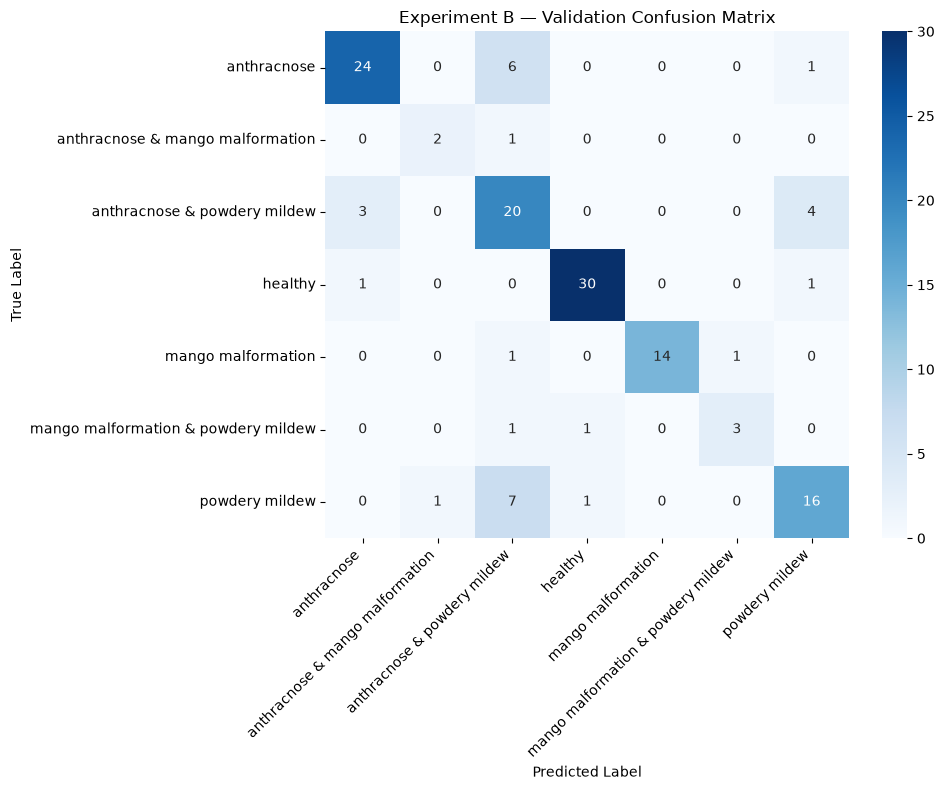

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_val_B = confusion_matrix(
    y_val_true_B,
    y_val_pred_B
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_val_B,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Experiment B — Validation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

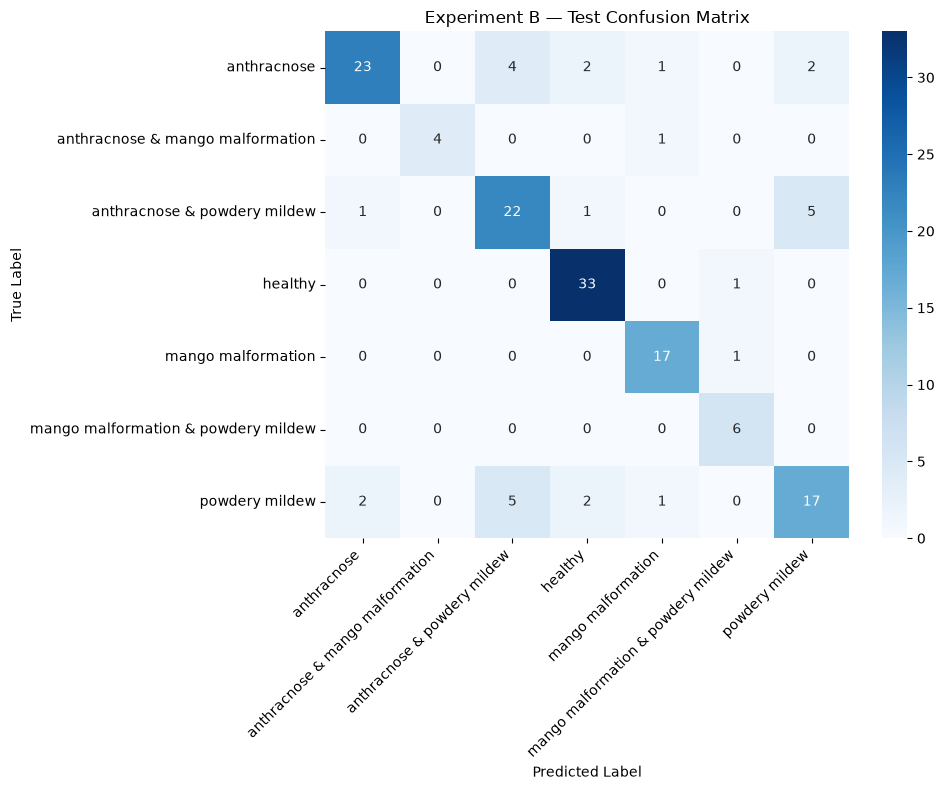

In [16]:
cm_test_B = confusion_matrix(
    y_test_true_B,
    y_test_pred_B
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_test_B,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Experiment B — Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
val_recall_B = recall_score(
    y_val_true_B,
    y_val_pred_B,
    average=None,
    zero_division=0
)

test_recall_B = recall_score(
    y_test_true_B,
    y_test_pred_B,
    average=None,
    zero_division=0
)

print("=" * 80)
print("EXPERIMENT B — PER-CLASS RECALL")
print("=" * 80)

for i, class_name in enumerate(class_names):
    print(
        f"{class_name:40s} "
        f"Validation: {val_recall_B[i]:.4f}   "
        f"Test: {test_recall_B[i]:.4f}"
    )

EXPERIMENT B — PER-CLASS RECALL
anthracnose                              Validation: 0.7742   Test: 0.7188
anthracnose & mango malformation         Validation: 0.6667   Test: 0.8000
anthracnose & powdery mildew             Validation: 0.7407   Test: 0.7586
healthy                                  Validation: 0.9375   Test: 0.9706
mango malformation                       Validation: 0.8750   Test: 0.9444
mango malformation & powdery mildew      Validation: 0.6000   Test: 1.0000
powdery mildew                           Validation: 0.6400   Test: 0.6296


In [18]:
print("=" * 70)
print("EXPERIMENT B — FINAL SUMMARY")
print("=" * 70)

print(f"Validation Accuracy    : {val_accuracy_B:.4f}")
print(f"Validation Macro F1    : {val_macro_f1_B:.4f}")
print(f"Validation Macro Recall: {val_macro_recall_B:.4f}")

print()

print(f"Test Accuracy          : {test_accuracy_B:.4f}")
print(f"Test Macro F1          : {test_macro_f1_B:.4f}")
print(f"Test Macro Recall      : {test_macro_recall_B:.4f}")

print("=" * 70)

EXPERIMENT B — FINAL SUMMARY
Validation Accuracy    : 0.7842
Validation Macro F1    : 0.7619
Validation Macro Recall: 0.7477

Test Accuracy          : 0.8079
Test Macro F1          : 0.8215
Test Macro Recall      : 0.8317
